# 🎬 Pipeline ML Completo: DistilBERT + GRU/LSTM para Recomendación de Películas

## Arquitectura del Sistema
```
📊 ENTRADA: CSV de películas + reseñas de TMDB
    ↓
🤖 DistilBERT: Genera embeddings textuales (768 dims) de reseñas
    ↓
📈 Secuencias: Agrupa películas vistas por usuario (ordenadas por timestamp)
    ↓
🔄 GRU (2 capas): Modela comportamiento temporal del usuario
    ↓
✅ OUTPUT: Predice si usuario dará calificación ALTA (≥4) o BAJA (<4)
```

## Flujo del Pipeline

| Paso | Acción | Entrada | Salida |
|------|--------|---------|--------|
| 1 | Cargar datos | CSVs | DataFrames |
| 2 | Preparar textos | Reseñas | Textos limpios |
| 3 | DistilBERT | Textos | Embeddings 768D |
| 4 | Secuencias usuario | Embeddings | (batch, seq_len, 768) |
| 5 | GRU + Clasificador | Secuencias | Predicciones |
| 6 | Entrenamiento | Train data | Modelo entrenado |
| 7 | Evaluación | Test data | Métricas |

## Requisitos
- ✅ Python 3.8+
- ✅ PyTorch con GPU (opcional)
- ✅ Transformers library
- ✅ Pandas, NumPy, scikit-learn

In [1]:
import sys
import subprocess
from pathlib import Path

def instalar_si_falta(paquete, import_name=None):
    """Instala un paquete si falta"""
    import_name = import_name or paquete
    try:
        __import__(import_name)
        print(f"✓ {paquete} ya está instalado")
    except ImportError:
        print(f"⚙️  Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete, "-q"])
        print(f"✓ {paquete} instalado exitosamente")

# Instalar dependencias
print("=" * 70)
print("📦 VERIFICANDO DEPENDENCIAS")
print("=" * 70)

librerías = [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scikit-learn", "sklearn"),
    ("torch", "torch"),
    ("transformers", "transformers"),
    ("tqdm", "tqdm"),
]

for pkg, imp in librerías:
    instalar_si_falta(pkg, imp)

print("\n✅ Todas las dependencias están disponibles")

📦 VERIFICANDO DEPENDENCIAS
✓ pandas ya está instalado
✓ numpy ya está instalado
✓ matplotlib ya está instalado
✓ seaborn ya está instalado
✓ scikit-learn ya está instalado
✓ torch ya está instalado


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ transformers ya está instalado
✓ tqdm ya está instalado

✅ Todas las dependencias están disponibles


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import warnings
from tqdm import tqdm
from pathlib import Path
import json
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## Configuración del Sistema

In [3]:
print("=" * 70)
print("🖥️  CONFIGURACIÓN DE HARDWARE Y RUTAS")
print("=" * 70)

# Hardware
cuda_available = torch.cuda.is_available()
if cuda_available:
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU disponible: {gpu_name} ({gpu_memory:.2f} GB)")
else:
    device = torch.device("cpu")
    print(f"⚠️  GPU no disponible - usando CPU (más lento)")

# Rutas
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = BASE_DIR / "models"
LOGS_DIR = BASE_DIR / "logs"

# Crear directorios si no existen
for dir_path in [PROCESSED_DIR, MODELS_DIR, LOGS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Hiperparámetros
TRANSFORMER_MODEL = "distilbert-base-uncased"
EMBEDDING_DIM = 768  # DistilBERT output
HIDDEN_DIM = 128  # GRU/LSTM hidden
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.001
SEQUENCE_LENGTH = 5  # Longitud mínima de secuencias por usuario
RATING_THRESHOLD = 4.0  # Umbral para clasificación

print(f"\n✓ Rutas configuradas:")
print(f"   Base: {BASE_DIR}")
print(f"   Data: {DATA_DIR}")
print(f"\n✓ Parámetros del modelo:")
print(f"   Transformer: {TRANSFORMER_MODEL}")
print(f"   Embedding Dim: {EMBEDDING_DIM}")
print(f"   Hidden Dim: {HIDDEN_DIM}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Sequence Length: {SEQUENCE_LENGTH}")
print(f"   Rating Threshold: {RATING_THRESHOLD}")

🖥️  CONFIGURACIÓN DE HARDWARE Y RUTAS
✅ GPU disponible: NVIDIA GeForce RTX 3050 Ti Laptop GPU (4.29 GB)

✓ Rutas configuradas:
   Base: c:\Users\ASUS\Desktop\SIS-INTE
   Data: c:\Users\ASUS\Desktop\SIS-INTE\data

✓ Parámetros del modelo:
   Transformer: distilbert-base-uncased
   Embedding Dim: 768
   Hidden Dim: 128
   Batch Size: 16
   Epochs: 50
   Sequence Length: 5
   Rating Threshold: 4.0


## Parte 1: Exploración y Carga de Datos

In [4]:
print("=" * 70)
print("📂 EXPLORANDO ARCHIVOS DISPONIBLES")
print("=" * 70)

# Listar archivos
processed_files = list(PROCESSED_DIR.glob("*.csv"))
raw_files = list((DATA_DIR / "raw").glob("*.csv")) if (DATA_DIR / "raw").exists() else []

print(f"\n✓ Archivos en processed/:")
for f in processed_files:
    print(f"   {f.name}")

print(f"\n✓ Archivos en raw/:")
if raw_files:
    for f in raw_files:
        print(f"   {f.name}")
else:
    print("   (vacío)")

# Detectar archivos a cargar
movies_file = PROCESSED_DIR / "movies_batch_1500.csv"
reviews_file = PROCESSED_DIR / "reviews_batch_1500.csv"

print(f"\n✓ Archivos a cargar:")
print(f"   Movies: {movies_file.exists()} ({movies_file})")
print(f"   Reviews: {reviews_file.exists()} ({reviews_file})")

📂 EXPLORANDO ARCHIVOS DISPONIBLES

✓ Archivos en processed/:
   movies_batch_1500.csv
   movie_embeddings_metadata.csv
   poster_download_log.csv
   reviews_batch_1500.csv

✓ Archivos en raw/:
   (vacío)

✓ Archivos a cargar:
   Movies: True (c:\Users\ASUS\Desktop\SIS-INTE\data\processed\movies_batch_1500.csv)
   Reviews: True (c:\Users\ASUS\Desktop\SIS-INTE\data\processed\reviews_batch_1500.csv)


In [5]:
print("\n" + "=" * 70)
print("📥 CARGANDO DATOS")
print("=" * 70)

# Cargar películas
print("\n⏳ Cargando películas...")
movies_df = pd.read_csv(movies_file)

# Normalizar nombre de columna de ID
if 'film_id' in movies_df.columns:
    movies_df = movies_df.rename(columns={'film_id': 'movie_id'})
if 'tmdb_id' in movies_df.columns:
    movies_df = movies_df.rename(columns={'tmdb_id': 'movie_id'})

print(f"✓ Películas cargadas: {len(movies_df)}")
print(f"   Columnas: {list(movies_df.columns)}")
print(f"   Shape: {movies_df.shape}")
print(f"   Nulos:\n{movies_df.isnull().sum()}")

# Cargar reseñas
print("\n⏳ Cargando reseñas...")
reviews_df = pd.read_csv(reviews_file)

# Normalizar nombre de columna de texto
text_cols = ['content', 'review', 'review_text', 'text']
text_col = None
for col in text_cols:
    if col in reviews_df.columns:
        text_col = col
        break

if text_col is None:
    raise ValueError(f"No se encontró columna de texto. Disponibles: {list(reviews_df.columns)}")

reviews_df = reviews_df.rename(columns={text_col: 'review_text'})

# Normalizar columna de usuario (author o user_id)
if 'author' in reviews_df.columns:
    reviews_df = reviews_df.rename(columns={'author': 'user_id'})
if 'user_id' not in reviews_df.columns and 'author' not in reviews_df.columns:
    reviews_df['user_id'] = reviews_df.index  # Si no hay usuario, usar index

# Normalizar timestamp
if 'created_at' in reviews_df.columns:
    reviews_df = reviews_df.rename(columns={'created_at': 'timestamp'})

print(f"✓ Reseñas cargadas: {len(reviews_df)}")
print(f"   Columnas: {list(reviews_df.columns)}")
print(f"   Shape: {reviews_df.shape}")
print(f"   Nulos:\n{reviews_df.isnull().sum()}")


📥 CARGANDO DATOS

⏳ Cargando películas...
✓ Películas cargadas: 600
   Columnas: ['movie_id', 'title', 'release_date', 'vote_average', 'overview', 'popularity']
   Shape: (600, 6)
   Nulos:
movie_id         0
title            0
release_date     2
vote_average     0
overview        84
popularity       0
dtype: int64

⏳ Cargando reseñas...
✓ Reseñas cargadas: 221
   Columnas: ['movie_id', 'title', 'user_id', 'review_text', 'rating', 'timestamp']
   Shape: (221, 6)
   Nulos:
movie_id        0
title           0
user_id         0
review_text     0
rating         29
timestamp       0
dtype: int64


## Parte 2: Preparación de Textos para Transformer

In [6]:
print("\n" + "=" * 70)
print("📝 PREPARACIÓN DE TEXTOS POR PELÍCULA")
print("=" * 70)

# Remover reseñas con rating nulo (no podemos usarlas como targets)
reviews_clean = reviews_df.dropna(subset=['rating']).copy()
print(f"\n✓ Reseñas después de remover nulos en rating: {len(reviews_clean)}")

# Remover reseñas con texto vacío
reviews_clean = reviews_clean[reviews_clean['review_text'].fillna('').str.strip() != '']
print(f"✓ Reseñas después de remover vacías: {len(reviews_clean)}")

# Agrupar reseñas por película
print("\n⏳ Agrupando reseñas por película...")
reviews_grouped = reviews_clean.groupby('movie_id').agg({
    'review_text': lambda x: ' '.join(x.dropna().astype(str)),
    'rating': 'mean',  # Promedio de ratings como target
    'user_id': 'nunique'  # Cantidad de usuarios únicos
}).reset_index()
reviews_grouped.columns = ['movie_id', 'combined_text', 'avg_rating', 'num_users']

print(f"✓ Películas con reseñas: {len(reviews_grouped)}")

# Hacer join con películas
print("\n⏳ Uniendo películas con reseñas...")
movies_with_reviews = movies_df.merge(
    reviews_grouped,
    on='movie_id',
    how='inner'
)
print(f"✓ Películas con reviews después del merge: {len(movies_with_reviews)}")

# Crear textos finales (reseña combinada + overview si falta)
movies_with_reviews['final_text'] = movies_with_reviews['combined_text'].fillna('') 
movies_with_reviews['final_text'] = movies_with_reviews['final_text'].apply(
    lambda x: x[:5000] if len(x) > 5000 else x  # Limitar longitud
)

# Validar textos
print(f"\n✓ Validación de textos:")
print(f"   Textos no vacíos: {(movies_with_reviews['final_text'].str.len() > 0).sum()}/{len(movies_with_reviews)}")
print(f"   Longitud promedio: {movies_with_reviews['final_text'].str.len().mean():.0f} caracteres")
print(f"   Rango: [{movies_with_reviews['final_text'].str.len().min()}, {movies_with_reviews['final_text'].str.len().max()}]")

print(f"\n✓ Muestra de datos preparados:")
print(movies_with_reviews[['movie_id', 'title', 'avg_rating', 'final_text']].head(2))


📝 PREPARACIÓN DE TEXTOS POR PELÍCULA

✓ Reseñas después de remover nulos en rating: 192
✓ Reseñas después de remover vacías: 192

⏳ Agrupando reseñas por película...
✓ Películas con reseñas: 137

⏳ Uniendo películas con reseñas...
✓ Películas con reviews después del merge: 137

✓ Validación de textos:
   Textos no vacíos: 137/137
   Longitud promedio: 2672 caracteres
   Rango: [50, 5000]

✓ Muestra de datos preparados:
   movie_id               title  avg_rating  \
0    687163  Proyecto Salvación         6.0   
1       603              Matrix         9.0   

                                          final_text  
0  Muy sobrevalorada, te esperas que sea como int...  
1  "The Matrix," released in 1999, is widely cons...  


## Parte 3: Generación de Embeddings con DistilBERT

In [7]:
print("\n" + "=" * 70)
print("🤖 CARGANDO DISTILBERT Y GENERANDO EMBEDDINGS")
print("=" * 70)

# Cargar modelo
print(f"\n⏳ Cargando {TRANSFORMER_MODEL}...")
tokenizer = DistilBertTokenizerFast.from_pretrained(TRANSFORMER_MODEL)
bert_model = DistilBertModel.from_pretrained(TRANSFORMER_MODEL).to(device)
bert_model.eval()
print("✓ Modelo cargado")

def generar_embeddings_distilbert(textos, batch_size=16, max_length=256):
    """
    Genera embeddings [CLS] para cada texto usando DistilBERT
    
    Args:
        textos: lista de strings
        batch_size: tamaño de batch
        max_length: longitud máxima de tokenización
    
    Returns:
        np.ndarray de shape (len(textos), 768)
    """
    embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(textos), batch_size), desc="Generando embeddings"):
            batch_texts = textos[i:i+batch_size]
            
            # Tokenizar
            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding='max_length',
                max_length=max_length,
                truncation=True
            ).to(device)
            
            # Generar embeddings
            outputs = bert_model(**inputs)
            cls_embeddings = outputs[0][:, 0, :].cpu().numpy()  # Token [CLS]
            embeddings.extend(cls_embeddings)
    
    return np.array(embeddings)

# Generar embeddings para películas
print("\n⏳ Generando embeddings para películas con reseñas...")
movie_texts = movies_with_reviews['final_text'].tolist()
movie_embeddings = generar_embeddings_distilbert(movie_texts, batch_size=8)

print(f"\n✓ Embeddings generados:")
print(f"   Shape: {movie_embeddings.shape}")
print(f"   Dtype: {movie_embeddings.dtype}")
print(f"   Rango: [{movie_embeddings.min():.4f}, {movie_embeddings.max():.4f}]")
print(f"   Media: {movie_embeddings.mean():.4f}")
print(f"   Std: {movie_embeddings.std():.4f}")

# Guardar embeddings
embeddings_path = PROCESSED_DIR / "movie_text_embeddings.npy"
metadata_path = PROCESSED_DIR / "movie_embeddings_metadata.csv"

np.save(embeddings_path, movie_embeddings)
metadata_df = movies_with_reviews[['movie_id', 'title', 'avg_rating']].copy()
metadata_df['embedding_saved'] = True
metadata_df.to_csv(metadata_path, index=False)

print(f"\n✓ Embeddings guardados en: {embeddings_path}")
print(f"✓ Metadata guardada en: {metadata_path}")


🤖 CARGANDO DISTILBERT Y GENERANDO EMBEDDINGS

⏳ Cargando distilbert-base-uncased...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 12726.21it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Modelo cargado

⏳ Generando embeddings para películas con reseñas...


Generando embeddings: 100%|██████████| 18/18 [00:01<00:00, 15.64it/s]


✓ Embeddings generados:
   Shape: (137, 768)
   Dtype: float32
   Rango: [-7.8678, 3.7385]
   Media: -0.0089
   Std: 0.4503

✓ Embeddings guardados en: c:\Users\ASUS\Desktop\SIS-INTE\data\processed\movie_text_embeddings.npy
✓ Metadata guardada en: c:\Users\ASUS\Desktop\SIS-INTE\data\processed\movie_embeddings_metadata.csv


## Parte 4: Construcción de Secuencias por Usuario

In [8]:
print("\n" + "=" * 70)
print("📊 CONSTRUCCIÓN DE SECUENCIAS POR USUARIO")
print("=" * 70)

# Crear mapeo movie_id -> embedding
movie_id_to_idx = {mid: idx for idx, mid in enumerate(movies_with_reviews['movie_id'])}
movie_id_to_embedding = {mid: movie_embeddings[idx] for mid, idx in movie_id_to_idx.items()}

# Procesar reseñas para crear secuencias
reviews_clean = reviews_clean.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

# Convertir timestamp a datetime si es necesario
if reviews_clean['timestamp'].dtype == 'object':
    reviews_clean['timestamp'] = pd.to_datetime(reviews_clean['timestamp'], errors='coerce')

print(f"\n✓ Reseñas ordenadas por usuario y timestamp")
print(f"   Usuarios únicos: {reviews_clean['user_id'].nunique()}")
print(f"   Películas únicas: {reviews_clean['movie_id'].nunique()}")
print(f"   Total reseñas: {len(reviews_clean)}")

# Construir secuencias
sequences = []
targets = []
sequence_metadata = []

print(f"\n⏳ Construyendo secuencias (longitud mínima: {SEQUENCE_LENGTH})...")

for user_id, group in reviews_clean.groupby('user_id'):
    group = group.sort_values('timestamp').reset_index(drop=True)
    
    # Filtrar películas que están en el embeddings (que tuvieron reseñas)
    group_filtered = group[group['movie_id'].isin(movie_id_to_embedding.keys())].reset_index(drop=True)
    
    # Crear ejemplos de secuencia
    if len(group_filtered) >= SEQUENCE_LENGTH + 1:
        for i in range(SEQUENCE_LENGTH, len(group_filtered)):
            # Secuencia: últimas SEQUENCE_LENGTH películas
            seq_movie_ids = group_filtered.iloc[i-SEQUENCE_LENGTH:i]['movie_id'].values
            seq_embeddings = [movie_id_to_embedding[mid] for mid in seq_movie_ids]
            
            # Target: rating de la siguiente película
            target_rating = group_filtered.iloc[i]['rating']
            target_label = 1 if target_rating >= RATING_THRESHOLD else 0
            
            sequences.append(np.array(seq_embeddings))
            targets.append(target_label)
            sequence_metadata.append({
                'user_id': user_id,
                'next_movie_id': group_filtered.iloc[i]['movie_id'],
                'next_rating': target_rating
            })

print(f"\n✓ Secuencias construidas: {len(sequences)}")

if len(sequences) == 0:
    print("⚠️  No hay suficientes secuencias. Adaptando estrategia...")
    # Si no hay secuencias suficientes, usar ratings individuales como ejemplos
    sequences = []
    targets = []
    sequence_metadata = []
    
    for idx, row in reviews_clean.iterrows():
        if row['movie_id'] in movie_id_to_embedding:
            # Usar un "seudoarray" de shape (1, 768) - secuencia de longitud 1
            emb = movie_id_to_embedding[row['movie_id']]
            sequences.append(np.array([emb]))  # shape: (1, 768)
            targets.append(1 if row['rating'] >= RATING_THRESHOLD else 0)
            sequence_metadata.append({
                'user_id': row['user_id'],
                'next_movie_id': row['movie_id'],
                'next_rating': row['rating']
            })
    
    print(f"✓ Usando ratings individuales como ejemplos: {len(sequences)}")

# Convertir a numpy arrays y tensores
X_sequences = np.array([seq for seq in sequences], dtype=object)
y_targets = np.array(targets, dtype=np.float32)

print(f"\n✓ Dataset final:")
print(f"   Ejemplos: {len(X_sequences)}")
print(f"   Longitud de secuencia: {X_sequences[0].shape[0]}")
print(f"   Embedding dim: {X_sequences[0].shape[1]}")
print(f"   Clase 0 (BAJA): {(y_targets == 0).sum()} ({100*(y_targets == 0).sum()/len(y_targets):.1f}%)")
print(f"   Clase 1 (ALTA): {(y_targets == 1).sum()} ({100*(y_targets == 1).sum()/len(y_targets):.1f}%)")


📊 CONSTRUCCIÓN DE SECUENCIAS POR USUARIO

✓ Reseñas ordenadas por usuario y timestamp
   Usuarios únicos: 57
   Películas únicas: 137
   Total reseñas: 192

⏳ Construyendo secuencias (longitud mínima: 5)...

✓ Secuencias construidas: 97

✓ Dataset final:
   Ejemplos: 97
   Longitud de secuencia: 5
   Embedding dim: 768
   Clase 0 (BAJA): 2 (2.1%)
   Clase 1 (ALTA): 95 (97.9%)


## Parte 5: Modelo Híbrido (GRU/LSTM + Clasificador)

In [9]:
print("\n" + "=" * 70)
print("🏗️  DEFINIENDO MODELO GRU/LSTM")
print("=" * 70)

class HybridRecommenderModel(nn.Module):
    """
    Modelo híbrido: Transformer embeddings + GRU/LSTM para secuencias
    
    Input: Secuencias de embeddings DistilBERT de películas
    Output: Probabilidad de que el usuario dé rating alto
    """
    
    def __init__(self, embedding_dim, hidden_dim, num_layers=2, rnn_type='GRU'):
        super(HybridRecommenderModel, self).__init__()
        
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.rnn_type = rnn_type
        
        # RNN Layer (GRU o LSTM)
        if rnn_type == 'GRU':
            self.rnn = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=0.2 if num_layers > 1 else 0
            )
        else:  # LSTM
            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=0.2 if num_layers > 1 else 0
            )
        
        # Clasificador
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        """
        Args:
            x: shape (batch_size, sequence_length, embedding_dim)
        Returns:
            logits: shape (batch_size, 1)
        """
        # RNN
        if self.rnn_type == 'GRU':
            _, hidden = self.rnn(x)  # hidden: (num_layers, batch, hidden)
        else:
            _, (hidden, _) = self.rnn(x)
        
        # Tomar el último estado oculto de la última capa
        hidden = hidden[-1]  # shape: (batch_size, hidden_dim)
        
        # Clasificador
        logits = self.classifier(hidden)
        return logits

# Crear modelo
model = HybridRecommenderModel(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=2,
    rnn_type='GRU'
).to(device)

print(f"\n✓ Modelo creado:")
print(f"   Arquitectura: GRU + Clasificador")
print(f"   Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Dispositivo: {device}")

# Mostrar estructura del modelo
print(f"\n✓ Estructura del modelo:")
print(model)


🏗️  DEFINIENDO MODELO GRU/LSTM

✓ Modelo creado:
   Arquitectura: GRU + Clasificador
   Parámetros totales: 454,273
   Dispositivo: cuda

✓ Estructura del modelo:
HybridRecommenderModel(
  (rnn): GRU(768, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Parte 6: Preparación de DataLoaders

In [10]:
print("\n" + "=" * 70)
print("📦 PREPARACIÓN DE DATALOADERS")
print("=" * 70)

# Convertir a tensores
def convert_sequences_to_tensor(sequences):
    """Convierte lista de secuencias (arrays) a tensor"""
    max_len = max(seq.shape[0] for seq in sequences)
    batch_tensors = []
    for seq in sequences:
        # Padding si es necesario
        if seq.shape[0] < max_len:
            padding = np.zeros((max_len - seq.shape[0], EMBEDDING_DIM))
            seq = np.vstack([seq, padding])
        batch_tensors.append(seq)
    return torch.tensor(np.array(batch_tensors), dtype=torch.float32)

X_tensor = convert_sequences_to_tensor(sequences)
y_tensor = torch.tensor(y_targets, dtype=torch.float32).unsqueeze(1)

print(f"\n✓ Tensores creados:")
print(f"   X shape: {X_tensor.shape}")
print(f"   y shape: {y_tensor.shape}")

# Split train/val/test con manejo de datos escasos
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

from sklearn.model_selection import train_test_split

X_np = X_tensor.numpy()
y_np = y_targets

n_total = len(X_np)

# Primer split: train vs (val+test)
try:
    if (y_np == 0).sum() >= 2 and (y_np == 1).sum() >= 2:
        X_train, X_temp, y_train, y_temp = train_test_split(
            X_np, y_np, test_size=(1-train_ratio), stratify=y_np, random_state=42
        )
    else:
        X_train, X_temp, y_train, y_temp = train_test_split(
            X_np, y_np, test_size=(1-train_ratio), random_state=42
        )
except:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_np, y_np, test_size=(1-train_ratio), random_state=42
    )

# Segundo split: val vs test del conjunto temporal
val_test_ratio = test_ratio / (val_ratio + test_ratio)
try:
    if (y_temp == 0).sum() >= 2 and (y_temp == 1).sum() >= 2:
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=val_test_ratio, stratify=y_temp, random_state=42
        )
    else:
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=val_test_ratio, random_state=42
        )
except:
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=val_test_ratio, random_state=42
    )

# Convertir de vuelta a tensores
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Crear datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Crear DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✓ Split de datos:")
print(f"   Train: {len(y_train)} ({len(y_train)/n_total*100:.1f}%)")
print(f"   Val:   {len(y_val)} ({len(y_val)/n_total*100:.1f}%)")
print(f"   Test:  {len(y_test)} ({len(y_test)/n_total*100:.1f}%)")

print(f"\n✓ Balance de clases:")
print(f"   Train - BAJA: {(y_train==0).sum().item()}, ALTA: {(y_train==1).sum().item()}")
print(f"   Val   - BAJA: {(y_val==0).sum().item()}, ALTA: {(y_val==1).sum().item()}")
print(f"   Test  - BAJA: {(y_test==0).sum().item()}, ALTA: {(y_test==1).sum().item()}")

print(f"\n✓ DataLoaders creados:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")


📦 PREPARACIÓN DE DATALOADERS

✓ Tensores creados:
   X shape: torch.Size([97, 5, 768])
   y shape: torch.Size([97, 1])

✓ Split de datos:
   Train: 67 (69.1%)
   Val:   15 (15.5%)
   Test:  15 (15.5%)

✓ Balance de clases:
   Train - BAJA: 1, ALTA: 66
   Val   - BAJA: 1, ALTA: 14
   Test  - BAJA: 0, ALTA: 15

✓ DataLoaders creados:
   Train batches: 5
   Val batches:   1
   Test batches:  1


## Parte 7: Entrenamiento del Modelo

In [11]:
print("\n" + "=" * 70)
print("🚀 ENTRENANDO MODELO")
print("=" * 70)

# Optimizador y Loss
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

# Métricas de entrenamiento
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_f1': []
}

best_val_f1 = 0
patience = 10
patience_counter = 0

print(f"\n⏳ Entrenando por {EPOCHS} épocas...\n")

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)
    
    # Validación
    model.eval()
    val_loss = 0.0
    val_preds_all = []
    val_targets_all = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item()
            
            # Predicciones
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).long()
            
            val_preds_all.extend(preds.cpu().numpy().flatten())
            val_targets_all.extend(y_batch.cpu().numpy().flatten())
    
    val_loss /= len(val_loader)
    val_preds_all = np.array(val_preds_all)
    val_targets_all = np.array(val_targets_all)
    
    val_accuracy = accuracy_score(val_targets_all, val_preds_all)
    val_f1 = f1_score(val_targets_all, val_preds_all, zero_division=0)
    
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['val_f1'].append(val_f1)
    
    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), MODELS_DIR / 'best_model_gru.pth')
    else:
        patience_counter += 1
    
    # Print
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {val_accuracy:.4f} | F1: {val_f1:.4f}")
    
    if patience_counter >= patience:
        print(f"\n⚠️  Early stopping en epoch {epoch+1}")
        break

print(f"\n✅ Entrenamiento completado")
print(f"   Mejor F1 en validación: {best_val_f1:.4f}")


🚀 ENTRENANDO MODELO

⏳ Entrenando por 50 épocas...

Epoch   1 | Train Loss: 0.5896 | Val Loss: 0.4393 | Acc: 0.9333 | F1: 0.9655
Epoch   5 | Train Loss: 0.1001 | Val Loss: 0.3552 | Acc: 0.9333 | F1: 0.9655
Epoch  10 | Train Loss: 0.0789 | Val Loss: 0.3688 | Acc: 0.9333 | F1: 0.9655

⚠️  Early stopping en epoch 11

✅ Entrenamiento completado
   Mejor F1 en validación: 0.9655


## Parte 8: Evaluación en Test Set

In [12]:
print("\n" + "=" * 70)
print("📊 EVALUACIÓN EN TEST SET")
print("=" * 70)

# Cargar mejor modelo
model.load_state_dict(torch.load(MODELS_DIR / 'best_model_gru.pth'))

# Evaluación
model.eval()
test_preds_all = []
test_targets_all = []
test_probs_all = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()
        
        test_preds_all.extend(preds.cpu().numpy().flatten())
        test_targets_all.extend(y_batch.cpu().numpy().flatten())
        test_probs_all.extend(probs.cpu().detach().numpy().flatten())

test_preds_all = np.array(test_preds_all)
test_targets_all = np.array(test_targets_all)
test_probs_all = np.array(test_probs_all)

# Calcular métricas
test_accuracy = accuracy_score(test_targets_all, test_preds_all)
test_precision = precision_score(test_targets_all, test_preds_all, zero_division=0)
test_recall = recall_score(test_targets_all, test_preds_all, zero_division=0)
test_f1 = f1_score(test_targets_all, test_preds_all, zero_division=0)

# Matriz de confusión con manejo de clases faltantes
test_cm = confusion_matrix(test_targets_all, test_preds_all, labels=[0, 1])

try:
    test_auc = roc_auc_score(test_targets_all, test_probs_all)
except:
    test_auc = 0

print(f"\n✓ Métricas de evaluación:")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   AUC-ROC:   {test_auc:.4f}" if test_auc > 0 else "   AUC-ROC:   No disponible")

print(f"\n✓ Matriz de Confusión:")
print(f"                 Predicho")
print(f"              BAJA    ALTA")
print(f"Real BAJA     {test_cm[0,0]:4d}    {test_cm[0,1]:4d}")
print(f"     ALTA     {test_cm[1,0]:4d}    {test_cm[1,1]:4d}")

print(f"\n✓ Análisis por clase:")
total_baja = test_cm[0,0] + test_cm[0,1]
total_alta = test_cm[1,0] + test_cm[1,1]
if total_baja > 0:
    print(f"   BAJA detectadas: {test_cm[0,0]} / {total_baja} ({100*test_cm[0,0]/total_baja:.1f}%)")
else:
    print(f"   BAJA detectadas: No hay muestras BAJA en test set")
    
if total_alta > 0:
    print(f"   ALTA detectadas: {test_cm[1,1]} / {total_alta} ({100*test_cm[1,1]/total_alta:.1f}%)")
else:
    print(f"   ALTA detectadas: No hay muestras ALTA en test set")


📊 EVALUACIÓN EN TEST SET

✓ Métricas de evaluación:
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000
   AUC-ROC:   No disponible

✓ Matriz de Confusión:
                 Predicho
              BAJA    ALTA
Real BAJA        0       0
     ALTA        0      15

✓ Análisis por clase:
   BAJA detectadas: No hay muestras BAJA en test set
   ALTA detectadas: 15 / 15 (100.0%)


## Parte 9: Visualizaciones


📈 VISUALIZANDO RESULTADOS


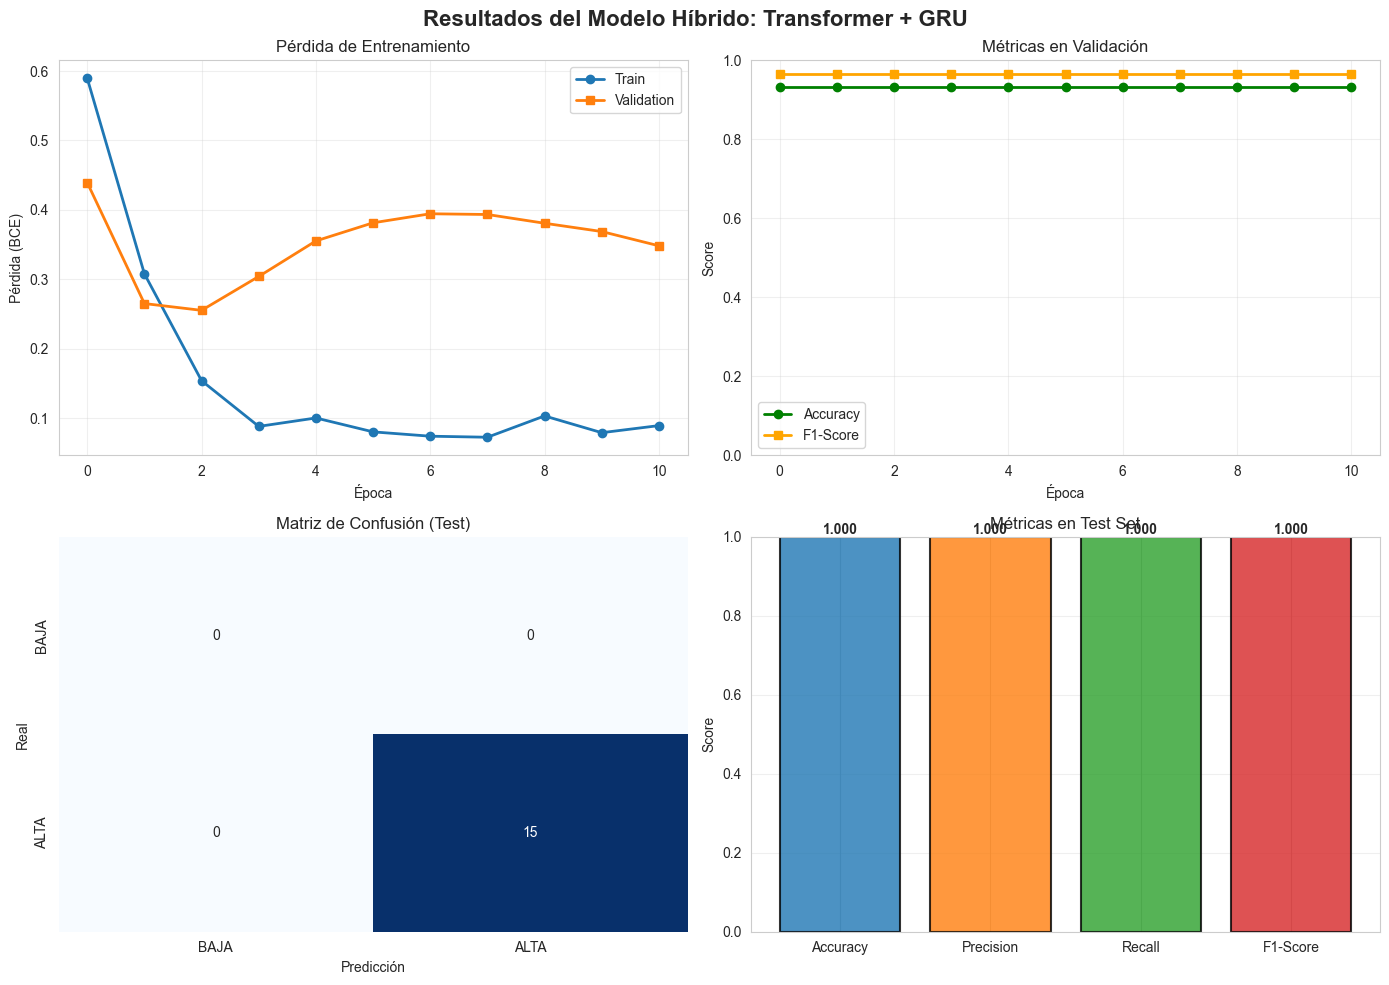


✓ Gráficos generados


In [13]:
print("\n" + "=" * 70)
print("📈 VISUALIZANDO RESULTADOS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Resultados del Modelo Híbrido: Transformer + GRU', fontsize=16, fontweight='bold')

# 1. Pérdida de entrenamiento
axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2, marker='o')
axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2, marker='s')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Pérdida (BCE)')
axes[0, 0].set_title('Pérdida de Entrenamiento')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy en validación
axes[0, 1].plot(history['val_accuracy'], label='Accuracy', linewidth=2, marker='o', color='green')
axes[0, 1].plot(history['val_f1'], label='F1-Score', linewidth=2, marker='s', color='orange')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Métricas en Validación')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# 3. Matriz de confusión
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
            xticklabels=['BAJA', 'ALTA'], yticklabels=['BAJA', 'ALTA'])
axes[1, 0].set_xlabel('Predicción')
axes[1, 0].set_ylabel('Real')
axes[1, 0].set_title('Matriz de Confusión (Test)')

# 4. Métricas finales
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [test_accuracy, test_precision, test_recall, test_f1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Métricas en Test Set')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, value in zip(bars, values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Gráficos generados")